Explore region behavior around sleep oscillating events

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [84]:
def _regionPETH(session,regs=None,when=None,limits=None,limits_isa=None):

    # load data
    R = rg.data.Regions(session,events='InfraSlowRhythm/infraslowaval',phases=when)
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    names = ['ripples','deltaWaves','spindles']
    events = {}
    for name in names:
        try:
            ev, _ = fma.data.loadEvents(session,name)
            events[name] = ev[name]['col1'] if 'col1' in ev[name] else ev[name]['peaks']
        except:
            events[name] = []
    isa = R.eventIntervals('slownr')
    off_on, on_off = isru.ISTransitions(isa,R.eventIntervals('slowavalnr'),[0.5,0.5])

    # assess coupling
    is_coupled = {}
    is_coupled['ripples'], is_coupled['deltasr'] = isru.isCoupled(events['ripples'],events['deltaWaves'],[0.05,0.25]) # [0.05,0.25]
    is_coupled['deltass'], is_coupled['spindles'] = isru.isCoupled(events['deltaWaves'],events['spindles'],[0.1,1.3]) # [0.1,1.3]
    is_coupled['deltaWaves'] = is_coupled['deltasr'] & is_coupled['deltass']
    #is_coupled['deltasr'][is_coupled['deltaWaves']] = False # deltasr contains delta waves just coupled to ripples
    #is_coupled['deltass'][is_coupled['deltaWaves']] = False # deltass contains delta waves just coupled to spindles
    # determine isa
    is_isa = {}
    for name in names:
        _, is_isa[name] = fma.general.restrict(events[name],isa,s_ind=True)

    fr = R.firingRate(regs=regs,norm=True)
    peth = {}
    for name in names:
        peth[name] = {}
        for isr in [False,True]: # False: ISA, True: no ISA
            peth[name][not isr] = {}
            for coupl in [False,True]: # False: coupled, True: uncoupled
                p, t, _ = fma.analysis.PETH(fr,events[name][(isr ^ is_isa[name]) & (coupl ^ is_coupled[name])],limits=limits) # (events, time, regions)
                peth[name][not isr][not coupl]  = xr.DataArray(p,dims=['event','t','reg'],coords={'t': t, 'reg': regs, 'rat': int(R.rat)})

    peth_isa = {}
    p, t, _ = fma.analysis.PETH(fr,off_on,limits=limits_isa)
    peth_isa['off_on'] = xr.DataArray(p,dims=['event','t','reg'],coords={'t': t, 'reg': regs, 'rat': int(R.rat)})
    p, t, _ = fma.analysis.PETH(fr,on_off,limits=limits_isa)
    peth_isa['on_off'] = xr.DataArray(p,dims=['event','t','reg'],coords={'t': t, 'reg': regs, 'rat': int(R.rat)})

    peth_oscill = []
    for name in names:
        peth_oscill.append([])
        _, t, p = fma.analysis.PETH(events[name],off_on,limits=limits_isa,n_bins=41,fast=True)  # (time,)
        peth_oscill[-1].append(p)
        _, t, p = fma.analysis.PETH(events[name],on_off,limits=limits_isa,n_bins=41,fast=True)  # (time,)
        peth_oscill[-1].append(p)
    peth_oscill = xr.DataArray(peth_oscill,dims=['name','tran','t'],coords={'name': names, 'tran': ['off_on','on_off'], 't': t, 'rat': int(R.rat)})

    return peth, peth_isa, peth_oscill

In [90]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][56]
print(session)
peth, peth_isa, peth_oscill = _regionPETH(session)

/mnt/hubel-data-149/Rat012/Rat012_2025-12-16/Rat012_2025-12-16.xml
implement!


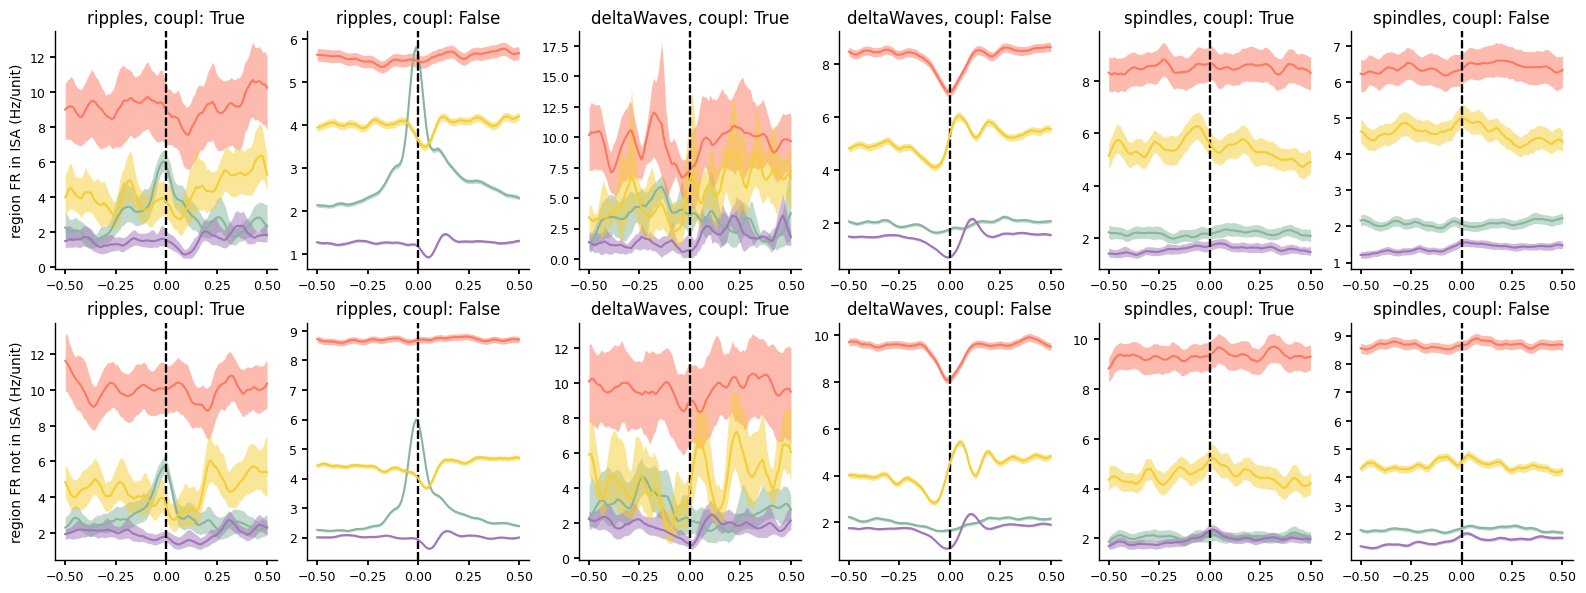

In [91]:
fig, ax = fma.plotting.makeFigure(n=[2,len(peth)*2],size=[40,15])
for i, (name, fr_p) in enumerate(peth.items()):
    for isa in [True,False]:
        for coupl in [True,False]:
            for r in fr_p[isa][coupl]['reg'].values:
                ax[int(not isa),2*i+(not coupl)].set_title(f'{name}, coupl: {coupl}')
                ax[int(not isa),2*i+(not coupl)].axvline(0,color='k',ls='--')
                fma.plotting.semPlot(fr_p[isa][coupl]['t'],fr_p[isa][coupl].sel(reg=r),color=isru.paperColors(r),ax=ax[int(not isa),2*i+(not coupl)])
ax[0,0].set(ylabel='region FR in ISA (Hz/unit)'); ax[1,0].set(ylabel='region FR not in ISA (Hz/unit)');

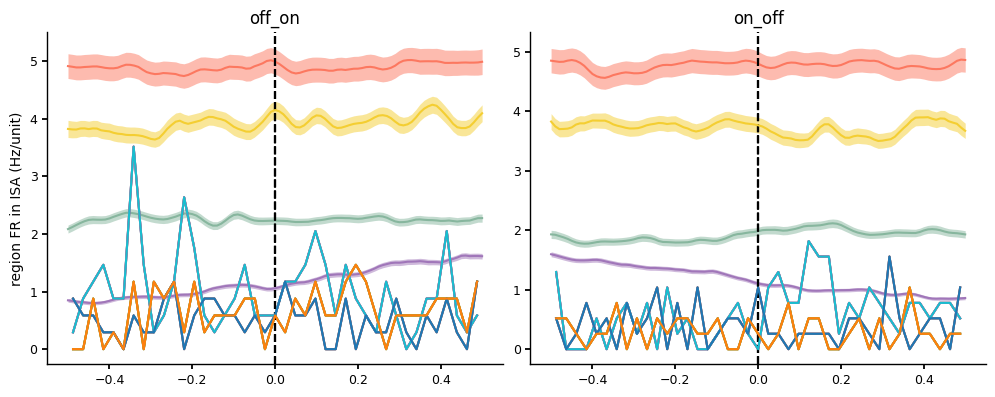

In [92]:
fig, ax = fma.plotting.makeFigure(n=[1,len(peth_isa)],size=[25,10])
for i, (name, fr_p) in enumerate(peth_isa.items()):
    for r in fr_p['reg'].values:
        ax[i].set_title(name)
        ax[i].axvline(0,color='k',ls='--')
        fma.plotting.semPlot(fr_p['t'],fr_p.sel(reg=r),color=isru.paperColors(r),ax=ax[i])
        ax[i].plot(peth_oscill['t'],peth_oscill.sel(tran=name).T*150)
ax[0].set(ylabel='region FR in ISA (Hz/unit)');